In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [27]:
import kagglehub

path = kagglehub.dataset_download("msambare/fer2013")

train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

In [29]:
IMG_SIZE = 48

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [30]:
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print(f"Классы: {class_names}")
print(f"Всего классов: {num_classes}")
print(f"Train: {len(full_train_dataset)}")
print(f"Test: {len(test_dataset)}")

Классы: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Всего классов: 7
Train: 28709
Test: 7178


In [31]:
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print(f"\nКлассы: {class_names}")
print(f"Всего классов: {num_classes}")
print(f"Полный Train: {len(full_train_dataset)} изображений")
print(f"Test: {len(test_dataset)} изображений")


Классы: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Всего классов: 7
Полный Train: 28709 изображений
Test: 7178 изображений


In [32]:
labels = [label for _, label in full_train_dataset.samples]

train_indices, val_indices = train_test_split(
    np.arange(len(full_train_dataset)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset, val_indices)

val_dataset.dataset.transform = test_transform

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

Train: 22967
Val:   5742
Test:  7178


In [33]:
BATCH_SIZE = 64
NUM_WORKERS = 0   

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if device.type == 'cuda' else False   
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if device.type == 'cuda' else False
)

In [34]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout2d(0.25)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout2d(0.25)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout2d(0.25)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.dropout4 = nn.Dropout2d(0.25)
        
        self.fc1 = nn.Linear(256 * 3 * 3, 512)
        self.fc_dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = self.dropout3(x)
        
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)
        x = self.dropout4(x)
        
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.fc_dropout(x)
        x = self.fc2(x)
        
        return x

model = EmotionCNN(num_classes=num_classes)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

Всего параметров: 1,572,551
Обучаемых параметров: 1,572,551


In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=5,
    factor=0.5
)

In [36]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader.dataset), correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader.dataset), correct / total


In [37]:
EPOCHS = 50
best_val_acc = 0.0
best_model_path = 'best_model_fer2013.pth'

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\nНачало обучение...")
print("=" * 50)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 30)
    
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
    
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

print("Обучение завершено")


Начало обучение...

Epoch 1/50
------------------------------


Validation: 100%|██████████| 90/90 [00:03<00:00, 29.42it/s]


Train Loss: 1.7911, Train Acc: 0.2612
Val Loss:   1.5973, Val Acc:   0.3774

Epoch 2/50
------------------------------


Validation: 100%|██████████| 90/90 [00:03<00:00, 29.47it/s]


Train Loss: 1.5982, Train Acc: 0.3642
Val Loss:   1.4664, Val Acc:   0.4171

Epoch 3/50
------------------------------


...

Train Loss: 0.8066, Train Acc: 0.6923
Val Loss:   1.2222, Val Acc:   0.5946

Epoch 49/50
------------------------------


Validation: 100%|██████████| 90/90 [00:03<00:00, 29.68it/s]


Train Loss: 0.7907, Train Acc: 0.6998
Val Loss:   1.2196, Val Acc:   0.5960

Epoch 50/50
------------------------------


Validation: 100%|██████████| 90/90 [00:03<00:00, 29.37it/s]

Train Loss: 0.7956, Train Acc: 0.6973
Val Loss:   1.2157, Val Acc:   0.5930
Обучение завершено


In [38]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

Testing: 100%|██████████| 113/113 [00:08<00:00, 13.05it/s]


              precision    recall  f1-score   support

       angry       0.49      0.48      0.48       958
     disgust       0.00      0.00      0.00       111
        fear       0.45      0.29      0.35      1024
       happy       0.80      0.84      0.82      1774
     neutral       0.53      0.60      0.56      1233
         sad       0.44      0.50      0.47      1247
    surprise       0.73      0.78      0.75       831

    accuracy                           0.59      7178
   macro avg       0.49      0.50      0.49      7178
weighted avg       0.58      0.59      0.58      7178



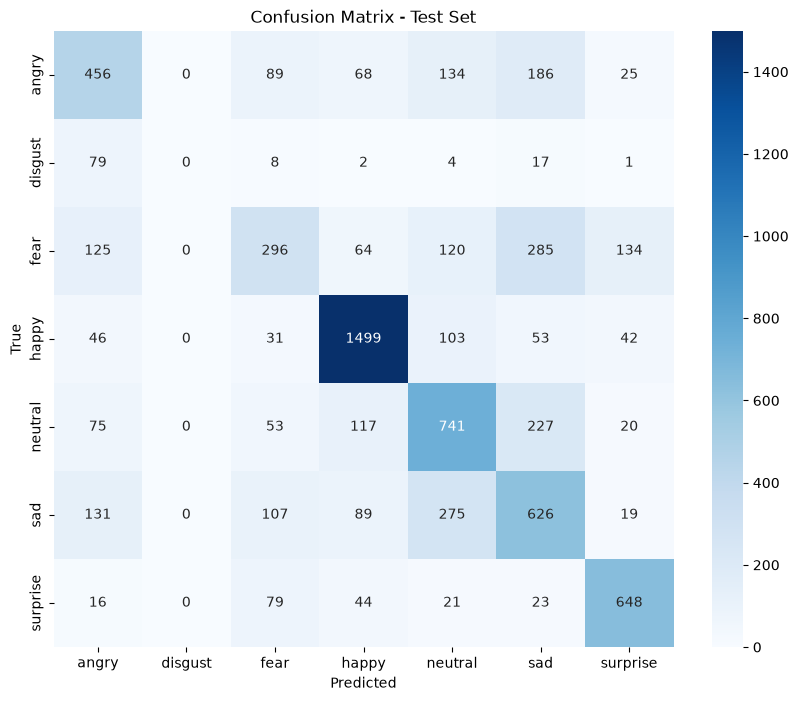

In [39]:
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.show()

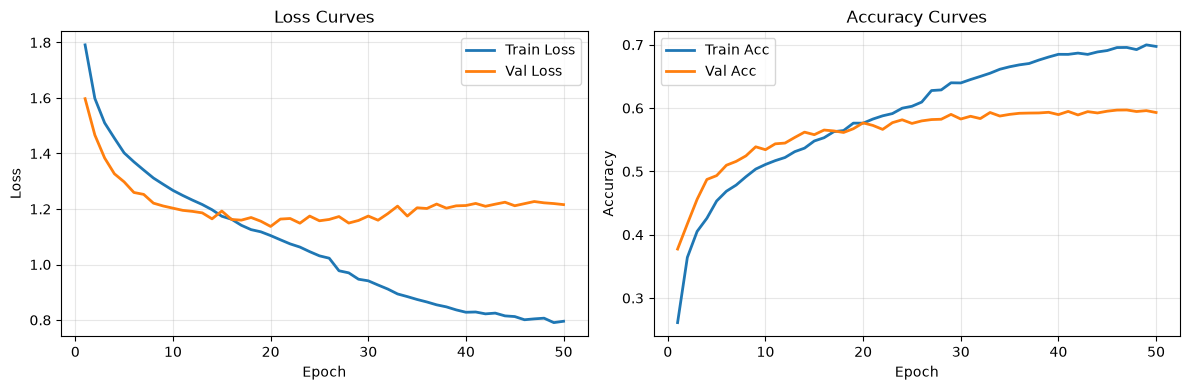

In [40]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', linewidth=2)
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accs)+1), train_accs, label='Train Acc', linewidth=2)
plt.plot(range(1, len(val_accs)+1), val_accs, label='Val Acc', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()